In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [3]:
german_credit = fetch_ucirepo(id=144)
X_raw = german_credit.data.features.copy()
y_raw = german_credit.data.targets.copy()

print(f'Shape features : {X_raw.shape}')
print(f'Distribution cible :\n{y_raw["class"].value_counts()}')
print(f'Missing values : {X_raw.isnull().sum().sum()}')
X_raw.head()

Shape features : (1000, 20)
Distribution cible :
class
1    700
2    300
Name: count, dtype: int64
Missing values : 0


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [5]:
df = X_raw.copy()
df['class'] = y_raw['class'].values

AGE_THRESHOLD = 25
df['age_group'] = (df['Attribute13'] >= AGE_THRESHOLD).astype(int)  # 1=senior, 0=jeune

feature_cols = [c for c in df.columns if c not in ['class', 'age_group']]
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()
num_cols = X_raw.select_dtypes(include='number').columns.tolist()

df_encoded = df.copy()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

df_encoded['target'] = (df_encoded['class'] == 2).astype(int)
print(df_encoded['target'].value_counts())

target
0    700
1    300
Name: count, dtype: int64


In [7]:
X = df_encoded[feature_cols].values
y = df_encoded['target'].values
sensitive = df_encoded['age_group'].values

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

num_indices = [feature_cols.index(c) for c in num_cols]
scaler = StandardScaler()
X_train_scaled = X_train.copy().astype(float)
X_test_scaled  = X_test.copy().astype(float)
X_train_scaled[:, num_indices] = scaler.fit_transform(X_train[:, num_indices])
X_test_scaled[:, num_indices]  = scaler.transform(X_test[:, num_indices])

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')

Train : 800 | Test : 200


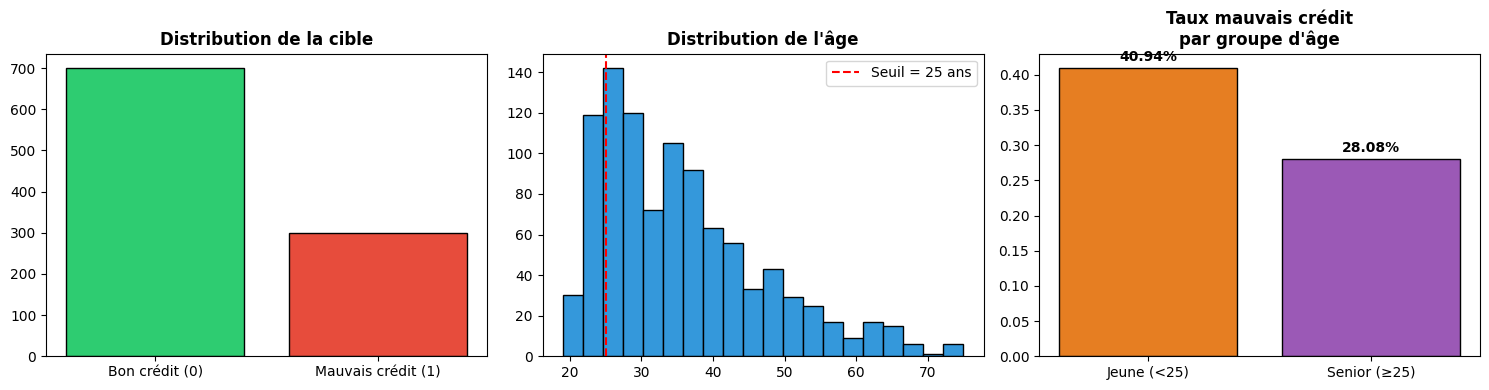

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Bon crédit (0)', 'Mauvais crédit (1)'],
            df_encoded['target'].value_counts().sort_index(),
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribution de la cible', fontweight='bold')

axes[1].hist(df['Attribute13'], bins=20, color='#3498db', edgecolor='black')
axes[1].axvline(AGE_THRESHOLD, color='red', linestyle='--', label=f'Seuil = {AGE_THRESHOLD} ans')
axes[1].set_title("Distribution de l'âge", fontweight='bold')
axes[1].legend()

rate_by_age = df_encoded.groupby('age_group')['target'].mean()
axes[2].bar(['Jeune (<25)', 'Senior (≥25)'], rate_by_age.values,
            color=['#e67e22', '#9b59b6'], edgecolor='black')
axes[2].set_title("Taux mauvais crédit\npar groupe d'âge", fontweight='bold')
for i, v in enumerate(rate_by_age.values):
    axes[2].text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
CLASS_WEIGHT = {0: 1, 1: 5}

def cost_matrix_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 0] * 5 + cm[0, 1] * 1

lr = LogisticRegression(max_iter=1000, class_weight=CLASS_WEIGHT, random_state=SEED)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             class_weight=CLASS_WEIGHT, random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print('Modèles entraînés ✓')

Modèles entraînés ✓


In [10]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Modèle'     : name,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'F1 (macro)' : f1_score(y_te, y_pred, average='macro'),
        'F1 (bad)'   : f1_score(y_te, y_pred, pos_label=1),
        'AUC-ROC'    : roc_auc_score(y_te, y_prob),
        'Coût total' : cost_matrix_score(y_te, y_pred),
    }

results_df = pd.DataFrame([
    evaluate_model('Logistic Regression', lr, X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf, X_test_scaled, y_test),
]).set_index('Modèle')

print(results_df.round(4).to_string())

                     Accuracy  F1 (macro)  F1 (bad)  AUC-ROC  Coût total
Modèle                                                                  
Logistic Regression     0.605      0.6033    0.5775   0.7923         103
Random Forest           0.730      0.6992    0.6029   0.8035         130


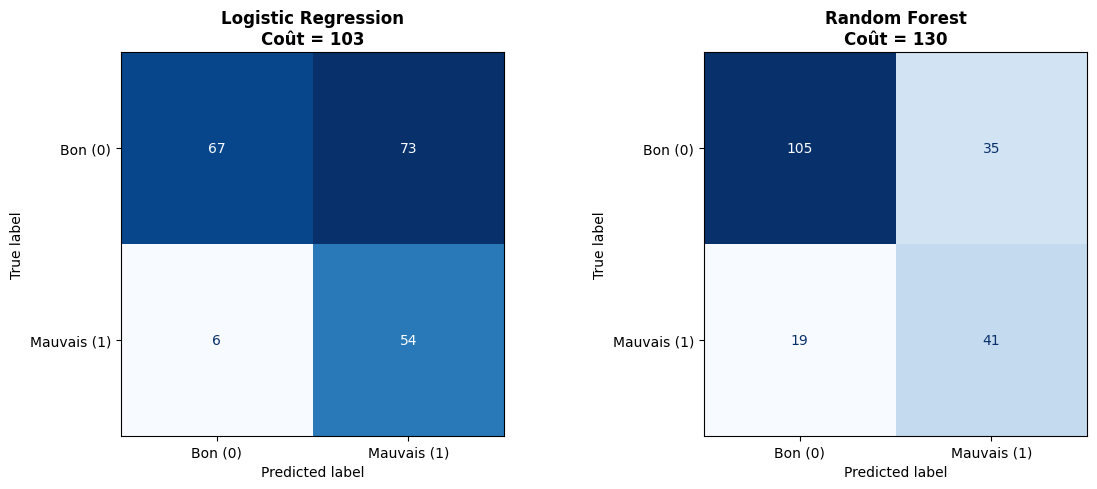

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                           display_labels=['Bon (0)', 'Mauvais (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nCoût = {cost_matrix_score(y_test, y_pred)}', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
    print(f'{name}: AUC={auc.mean():.4f}±{auc.std():.4f} | F1={f1.mean():.4f}±{f1.std():.4f}')

Logistic Regression: AUC=0.7763±0.0554 | F1=0.6048±0.0257
Random Forest: AUC=0.7829±0.0411 | F1=0.6960±0.0329


In [13]:
def fairness_metrics(y_true, y_pred, sensitive, model_name=''):
    mask_young  = sensitive == 0
    mask_senior = sensitive == 1
    pr_young  = (y_pred[mask_young]  == 0).mean()
    pr_senior = (y_pred[mask_senior] == 0).mean()
    DI  = pr_young / pr_senior
    EOD = y_pred[mask_young & (y_true==1)].mean() - y_pred[mask_senior & (y_true==1)].mean()
    print(f'\n=== {model_name} ===')
    print(f'  DI  = {DI:.3f}  (idéal=1.0, seuil légal ≥ 0.8)')
    print(f'  EOD = {EOD:.3f}  (idéal=0.0)')

fairness_metrics(y_test, lr.predict(X_test_scaled), s_test, 'Logistic Regression')
fairness_metrics(y_test, rf.predict(X_test_scaled), s_test, 'Random Forest')


=== Logistic Regression ===
  DI  = 0.370  (idéal=1.0, seuil légal ≥ 0.8)
  EOD = 0.069  (idéal=0.0)

=== Random Forest ===
  DI  = 0.656  (idéal=1.0, seuil légal ≥ 0.8)
  EOD = 0.078  (idéal=0.0)


In [14]:
import pickle
checkpoint = {
    'X_train': X_train_scaled, 'X_test': X_test_scaled,
    'y_train': y_train, 'y_test': y_test,
    's_train': s_train, 's_test': s_test,
    'feature_cols': feature_cols, 'scaler': scaler, 'le_dict': le_dict,
    'baseline_lr': lr, 'baseline_rf': rf, 'SEED': SEED,
}
with open('checkpoint_etapes1_2.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)
print('Checkpoint sauvegardé ✓')

Checkpoint sauvegardé ✓
